In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('news.csv')

In [3]:
df.columns

Index(['id', 'title', 'text', 'label'], dtype='str')

In [4]:
df.head()

,id,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      6335 non-null   int64
 1   title   6335 non-null   str  
 2   text    6335 non-null   str  
 3   label   6335 non-null   str  
dtypes: int64(1), str(3)
memory usage: 198.1 KB


In [6]:
df.describe()

,id
count,6335.000000
mean,5280.415627
std,3038.503953
min,2.000000
25%,2674.500000
50%,5271.000000
75%,7901.000000
max,10557.000000


In [7]:
df['context'] = df["title"] + " " + df["text"]

df = df.drop(columns=['id',  "title", "text"])

In [8]:
df['label'].value_counts()

label
REAL    3171
FAKE    3164
Name: count, dtype: int64

In [10]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
label      0
context    0
dtype: int64


In [11]:
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Number of duplicate rows:
29


In [13]:
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\USER\AppData\Local\Temp\ipykernel_17188\3580716488.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


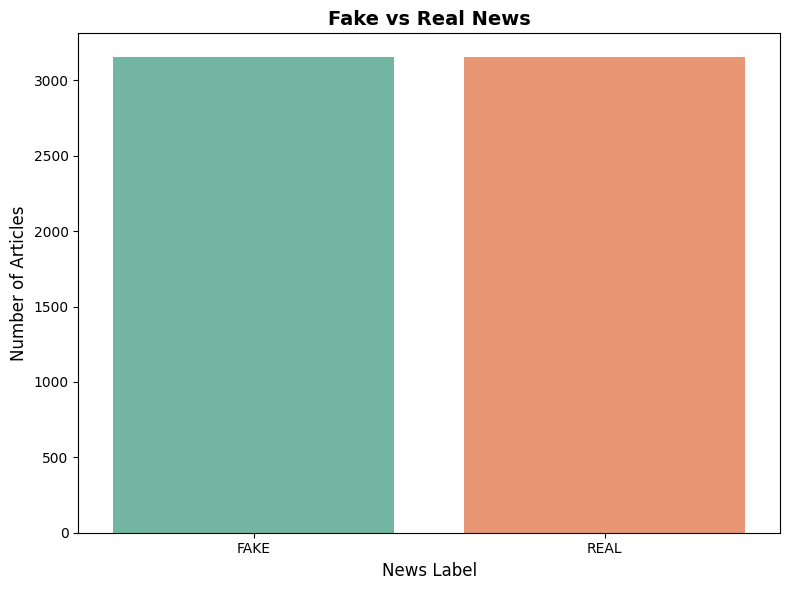

In [21]:
plt.figure(figsize=(8, 6))

# Added palette and legend=False to prevent redundant legends and warnings
sns.countplot(
    data=df, 
    x='label', 
    palette='Set2', 
    legend=False
)

plt.title("Fake vs Real News", fontsize=14, fontweight='bold')
plt.xlabel("News Label", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)  # Fixed typo: "Articals" -> "Articles"

plt.tight_layout()
plt.show()

In [22]:
label_prsantage = df["label"].value_counts(normalize=True)*100
print(f"prsantage of fake or real news: {label_prsantage}")

prsantage of fake or real news: label
REAL    50.015858
FAKE    49.984142
Name: proportion, dtype: float64


In [24]:
df

,label,context
0,FAKE,You Can Smell Hillary’s Fear Daniel Greenfield...
1,FAKE,Watch The Exact Moment Paul Ryan Committed Pol...
2,REAL,Kerry to go to Paris in gesture of sympathy U....
3,FAKE,Bernie supporters on Twitter erupt in anger ag...
4,REAL,The Battle of New York: Why This Primary Matte...
...,...,...
6330,REAL,State Department says it can't find emails fro...
6331,FAKE,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...
6332,FAKE,Anti-Trump Protesters Are Tools of the Oligarc...
6333,REAL,"In Ethiopia, Obama seeks progress on peace, se..."


In [25]:
df["text_length"] = df["context"].fillna("").str.len()

print("\nArticle length statistics:")
print(df["text_length"].describe())


Article length statistics:
count      6306.000000
mean       4773.718046
std        5099.766686
min          14.000000
25%        1801.000000
50%        3709.000000
75%        6250.000000
max      115448.000000
Name: text_length, dtype: float64


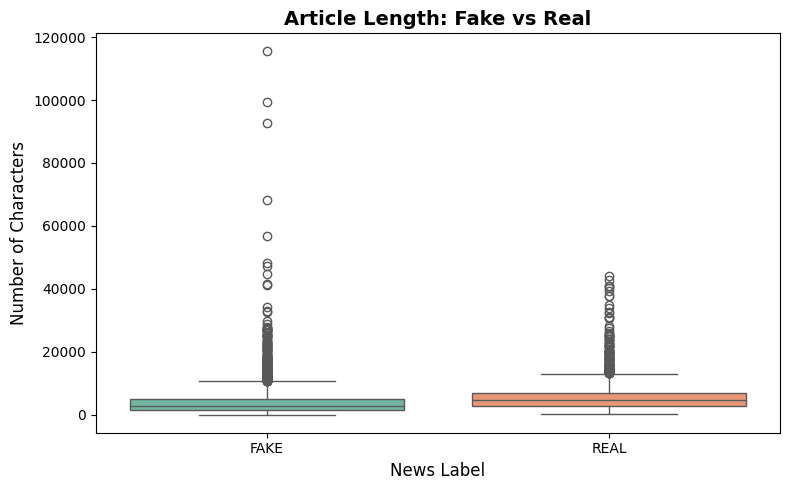

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="label",y="text_length", hue="label", palette="Set2",legend=False)

plt.title("Article Length: Fake vs Real", fontsize=14, fontweight="bold")
plt.xlabel("News Label", fontsize=12)
plt.ylabel("Number of Characters", fontsize=12)
plt.tight_layout()
plt.show()

In [32]:
df.head(5)

,label,context,text_length,Context_length
0,FAKE,You Can Smell Hillary’s Fear Daniel Greenfield...,7547,7547
1,FAKE,Watch The Exact Moment Paul Ryan Committed Pol...,2732,2732
2,REAL,Kerry to go to Paris in gesture of sympathy U....,2587,2587
3,FAKE,Bernie supporters on Twitter erupt in anger ag...,2745,2745
4,REAL,The Battle of New York: Why This Primary Matte...,1889,1889


In [34]:
df.drop(columns=["Context_length"])

,label,context,text_length
0,FAKE,You Can Smell Hillary’s Fear Daniel Greenfield...,7547
1,FAKE,Watch The Exact Moment Paul Ryan Committed Pol...,2732
2,REAL,Kerry to go to Paris in gesture of sympathy U....,2587
3,FAKE,Bernie supporters on Twitter erupt in anger ag...,2745
4,REAL,The Battle of New York: Why This Primary Matte...,1889
...,...,...,...
6330,REAL,State Department says it can't find emails fro...,4146
6331,FAKE,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,14383
6332,FAKE,Anti-Trump Protesters Are Tools of the Oligarc...,12041
6333,REAL,"In Ethiopia, Obama seeks progress on peace, se...",7059


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("y train samples:", len(y_train))
print("Testing samples:", len(X_test))
print("y test samples:", len(y_test))

Training samples: 5044
y train samples: 5044
Testing samples: 1262
y test samples: 1262


In [47]:
print("Training samples:", len(X_train))
print("y train samples:", len(y_train))

Training samples: 5044
y train samples: 1262


In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=50000,
    ngram_range=(1, 2)
)

# Learn vocabulary from TRAINING data
# and convert training text into numbers
X_train_tfidf = tfidf.fit_transform(X_train)

# Convert TEST text using the vocabulary
# learned from training data
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF:", X_train_tfidf.shape)
print("Testing TF-IDF:", X_test_tfidf.shape)

Training TF-IDF: (5044, 50000)
Testing TF-IDF: (1262, 50000)


In [50]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

Model trained successfully!


In [51]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9160063391442155

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.90      0.93      0.92       631
        REAL       0.93      0.90      0.91       631

    accuracy                           0.92      1262
   macro avg       0.92      0.92      0.92      1262
weighted avg       0.92      0.92      0.92      1262



In [52]:
results = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred
})

wrong = results[results["actual"] != results["predicted"]]

print("Wrong predictions:", len(wrong))

print(wrong.head(10))

Wrong predictions: 106
                                                   text actual predicted
1030  Cuba has a possible lung cancer vaccine that A...   REAL      FAKE
3094  Profit sharing was supposed to be a silver bul...   REAL      FAKE
2180  Kenyan refugee kills co-worker, self Kenyan re...   FAKE      REAL
5484  'Specific info' forces WikiLeaks to move antic...   REAL      FAKE
2315  An open letter to Mr. Khizr Khan Editor's note...   REAL      FAKE
592   ‘A noun, a verb and Donald Trump’: Rubio seeks...   FAKE      REAL
1161  The Sad Evolution Of Education Summed Up By On...   FAKE      REAL
4919  Glenn Reynolds: Don't be a sucker for socialis...   REAL      FAKE
1913  Obama's long-view foreign policy: why he think...   REAL      FAKE
2961  Load of manure dumped at Democratic headquarte...   FAKE      REAL


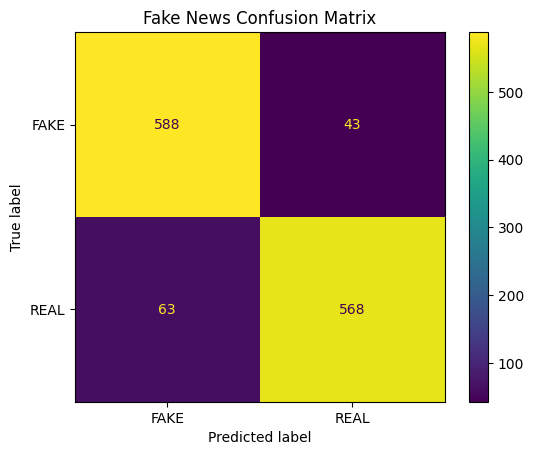

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()

plt.title("Fake News Confusion Matrix")
plt.show()